In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
%matplotlib inline

In [2]:
plt.rcParams['font.sans-serif'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False
# plt.rcParams['figure.figsize'] = (12,7)

In [3]:
df = pd.read_csv(r"D:\materials\数据分析素材\python_project\project_byMyself\datasets\walmart_data.csv")
df.head(10)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969
5,1000003,P00193542,M,26-35,15,A,3,0,1,15227
6,1000004,P00184942,M,46-50,7,B,2,1,1,19215
7,1000004,P00346142,M,46-50,7,B,2,1,1,15854
8,1000004,P0097242,M,46-50,7,B,2,1,1,15686
9,1000005,P00274942,M,26-35,20,A,1,1,8,7871


In [4]:
columns_map = {
    'User_ID':'用户号',
    'Product_ID':'商品号',
    'Gender':'性别1',
    'Age':'年龄',
    'Occupation':'职位',
    'City_Category':'城市类别',
    'Stay_In_Current_City_Years':'居住在当前城市时长',
    'Marital_Status':'婚姻状况1',
    'Product_Category':'商品类别',
    'Purchase':'购买金额'
}
df = df.rename(columns=columns_map)
gender_map = {
    'F':'女',
    'M':'男'
}
marital_map = {
    1:'已婚',
    0:'未婚'
}
df['性别'] = df['性别1'].map(gender_map)
df['婚姻状况'] = df['婚姻状况1'].map(marital_map)
df.head()

,用户号,商品号,性别1,年龄,职位,城市类别,居住在当前城市时长,婚姻状况1,商品类别,购买金额,性别,婚姻状况
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370,女,未婚
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200,女,未婚
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422,女,未婚
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057,女,未婚
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969,男,未婚


In [5]:
df.isnull().sum()  # 无缺失值

用户号          0
商品号          0
性别1          0
年龄           0
职位           0
城市类别         0
居住在当前城市时长    0
婚姻状况1        0
商品类别         0
购买金额         0
性别           0
婚姻状况         0
dtype: int64

In [6]:
df.describe()

,用户号,职位,婚姻状况1,商品类别,购买金额
count,5.500680e+05,550068.000000,550068.000000,550068.000000,550068.000000
mean,1.003029e+06,8.076707,0.409653,5.404270,9263.968713
std,1.727592e+03,6.522660,0.491770,3.936211,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,12.000000
25%,1.001516e+06,2.000000,0.000000,1.000000,5823.000000
50%,1.003077e+06,7.000000,0.000000,5.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,23961.000000


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   用户号        550068 non-null  int64
 1   商品号        550068 non-null  str  
 2   性别1        550068 non-null  str  
 3   年龄         550068 non-null  str  
 4   职位         550068 non-null  int64
 5   城市类别       550068 non-null  str  
 6   居住在当前城市时长  550068 non-null  str  
 7   婚姻状况1      550068 non-null  int64
 8   商品类别       550068 non-null  int64
 9   购买金额       550068 non-null  int64
 10  性别         550068 non-null  str  
 11  婚姻状况       550068 non-null  str  
dtypes: int64(5), str(7)
memory usage: 64.1 MB


#### 1.对于用户整体分析 哪个年龄段消费力最强？不同年龄偏好哪些商品类别


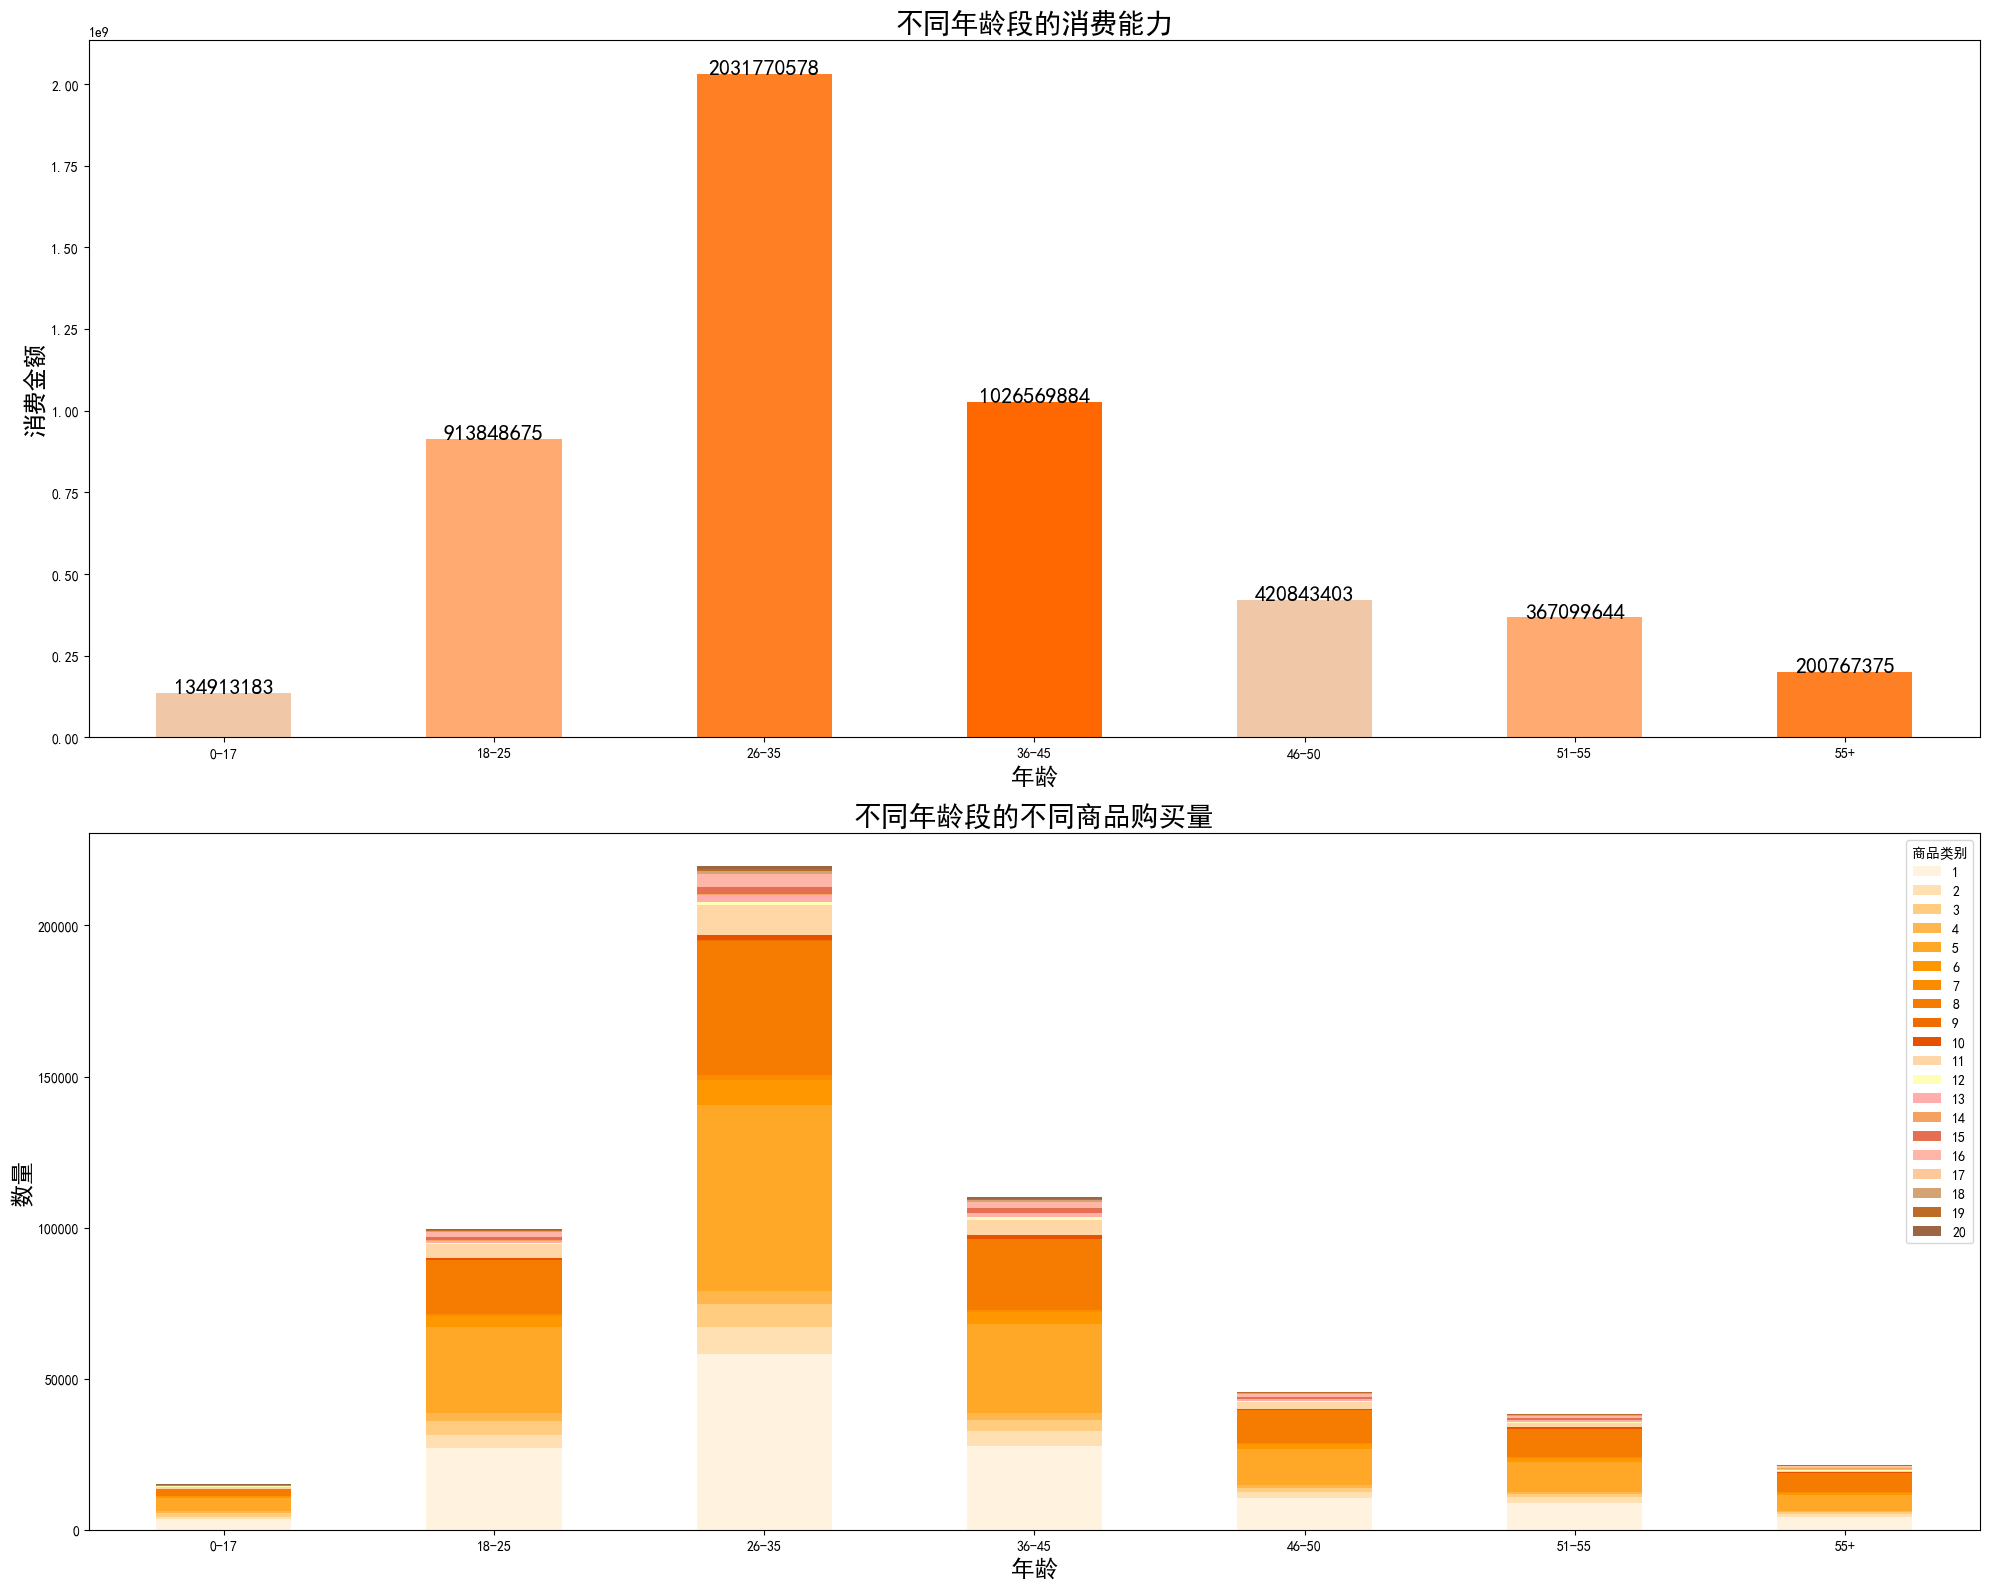

In [8]:
plt.figure(figsize=(20,16))
ax1 = plt.subplot(211)
df_age_purchase = df.groupby('年龄')['购买金额'].sum()
df_age_purchase.plot(kind='bar',ax=ax1,color=['#f0c8a8', '#ffaa71', '#ff7f24', '#FF6700'])
plt.title('不同年龄段的消费能力',weight='bold',fontsize=20)
plt.xlabel('年龄',fontsize=17)
plt.ylabel('消费金额',fontsize=17)
plt.xticks(rotation=0)
for x,y in enumerate(df_age_purchase):
    plt.text(x,y+20,y,ha='center',fontsize=16)

ax2 = plt.subplot(212)
df.groupby(['年龄','商品类别'])['商品号'].count().unstack().plot(kind='bar',stacked=True,ax=ax2,color = [
    '#fff3e0',
    '#ffe0b2',
    '#ffcc80',
    '#ffb74d',
    '#ffa726',
    '#ff9800',
    '#fb8c00',
    '#f57c00',
    '#ef6c00',
    '#e65100',
    '#ffd6a5',
    '#fdffb6',
    '#ffadad',
    '#f4a261',
    '#e76f51',
    '#ffb5a7',
    '#fec89a',
    '#d4a373',
    '#bc6c25',
    '#9c6644'
])
plt.title('不同年龄段的不同商品购买量',weight='bold',fontsize=20)
plt.xlabel('年龄',fontsize=17)
plt.ylabel('数量',fontsize=17)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

1.26-35年龄段消费能力最强，其次为36-45、18-25,可见青年中年群体为消费主力，0-17年龄段消费能力最弱。

2.每个年龄段都偏好5、1、8商品。

#### 2.已婚男女vs 未婚男女，谁消费更高？商品偏好差异？ 

(array([0, 1, 2, 3]),
 [Text(0, 0, '(已婚, 女)'),
  Text(1, 0, '(已婚, 男)'),
  Text(2, 0, '(未婚, 女)'),
  Text(3, 0, '(未婚, 男)')])

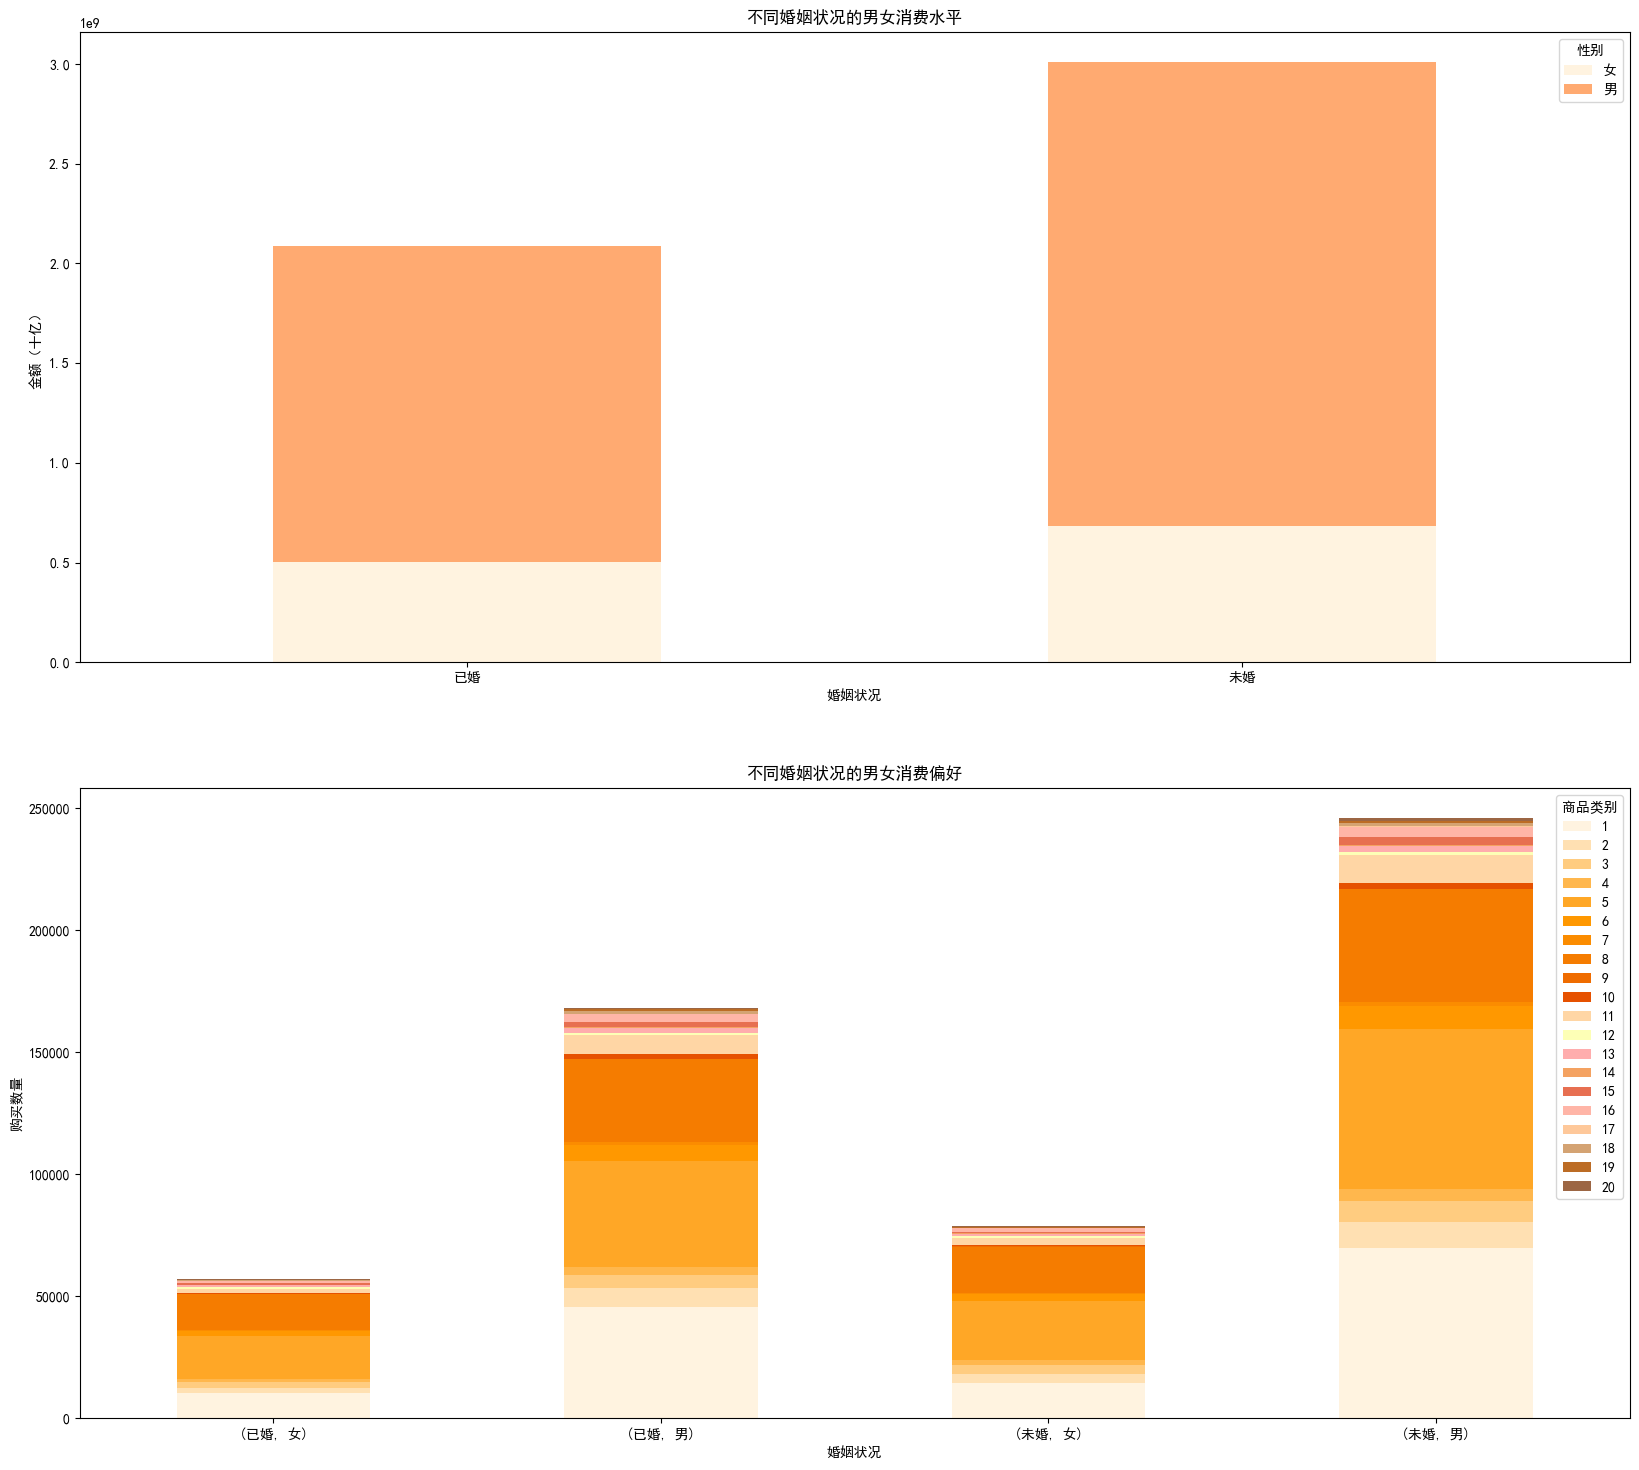

In [104]:
plt.figure(figsize=(20,18))
ax1 = plt.subplot(211)
df.groupby(['婚姻状况','性别'])['购买金额'].sum().unstack().plot(kind='bar',stacked=True,ax=ax1,color=['#fff3e0','#ffaa71'])
plt.title('不同婚姻状况的男女消费水平',fontsize=12,weight='bold')
plt.xlabel('婚姻状况',fontsize=10)
plt.ylabel('金额（十亿）',fontsize=10)
plt.xticks(rotation=0)

ax2 = plt.subplot(212)
df.groupby(['婚姻状况','性别'])['商品类别'].value_counts().unstack().plot(kind='bar',stacked=True,ax=ax2,color = [
    '#fff3e0',
    '#ffe0b2',
    '#ffcc80',
    '#ffb74d',
    '#ffa726',
    '#ff9800',
    '#fb8c00',
    '#f57c00',
    '#ef6c00',
    '#e65100',
    '#ffd6a5',
    '#fdffb6',
    '#ffadad',
    '#f4a261',
    '#e76f51',
    '#ffb5a7',
    '#fec89a',
    '#d4a373',
    '#bc6c25',
    '#9c6644'
])
plt.title('不同婚姻状况的男女消费偏好',fontsize=12,weight='bold')
plt.xlabel('婚姻状况',fontsize=10)
plt.ylabel('购买数量',fontsize=10)
plt.xticks(rotation=0)

3.未婚人士的消费水平高于已婚人士，且已婚男士消费水平远高于已婚女士，未婚男士的消费水平也远高于未婚女士。

4.已婚女士偏好5，已婚男士偏好5、1，未婚女士偏好5，未婚男士偏好5、1。

#### 3.A/B/C三类城市的人均消费水平对比？

(array([0, 1, 2]), [Text(0, 0, 'A'), Text(1, 0, 'B'), Text(2, 0, 'C')])

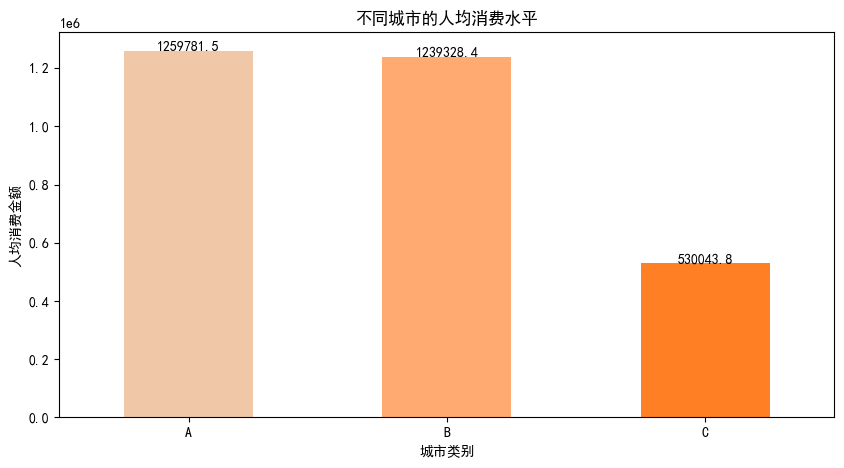

In [10]:
plt.figure(figsize=(10,5))
by_city = round(df.groupby('城市类别')['购买金额'].sum()/(df.groupby('城市类别')['用户号'].apply(lambda x:len(x.drop_duplicates()))),1)
by_city.plot(kind='bar',color=['#f0c8a8', '#ffaa71', '#ff7f24'])
for x,y in enumerate(by_city):
    plt.text(x,y+300,y,ha='center')

plt.title('不同城市的人均消费水平',fontsize=12,weight='bold')
plt.xlabel('城市类别',fontsize=10)
plt.ylabel('人均消费金额',fontsize=10)
plt.xticks(rotation=0)

5.A城市消费水平最高，其次是B，C最低，但是A与B消费水平相当接近。

#### 4.前10%（高价值）用户有什么共同特征？（年龄、性别、城市、婚姻、职位）

In [12]:
top_user_number = int(df['用户号'].nunique()*0.1)
top_user = df.groupby('用户号')['购买金额'].sum().sort_values(ascending=False).head(top_user_number)
top_user_table = df[df['用户号'].isin(top_user.index)][['用户号','年龄','性别','城市类别','婚姻状况','职位']].drop_duplicates()
top_user_table

,用户号,年龄,性别,城市类别,婚姻状况,职位
29,1000010,36-45,女,B,已婚,1
196,1000036,26-35,男,B,未婚,3
264,1000048,26-35,男,B,已婚,4
304,1000053,26-35,男,B,未婚,0
342,1000058,26-35,男,B,未婚,2
...,...,...,...,...,...,...
38771,1005972,26-35,女,B,未婚,20
38878,1005996,26-35,女,B,已婚,0
38910,1006000,46-50,男,B,已婚,17
39029,1006016,46-50,男,B,已婚,1


Text(0, 0.5, '')

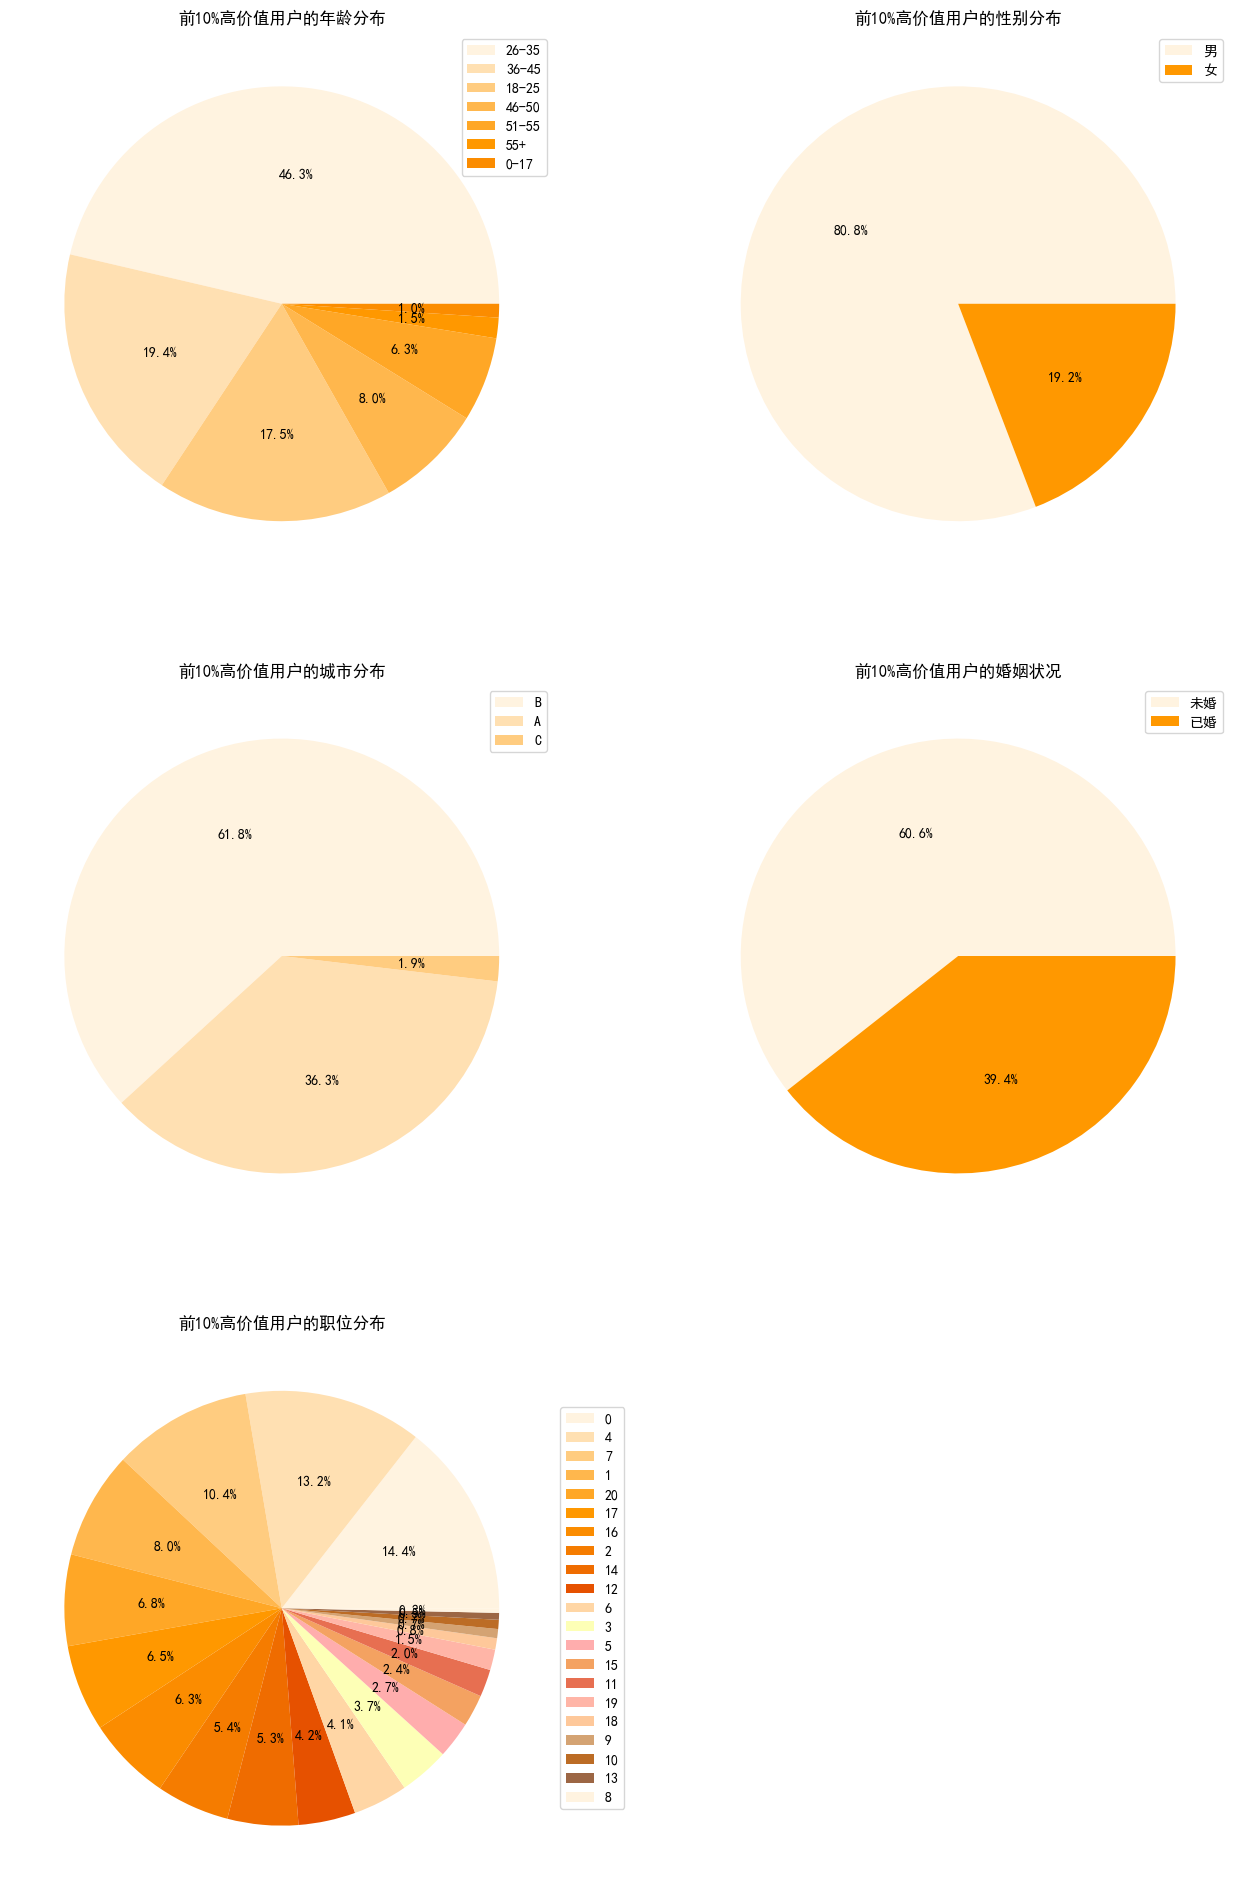

In [13]:
plt.figure(figsize=(16,24))

plt.subplot(321)
p1 = top_user_table['年龄'].value_counts()
p1.plot(kind='pie',autopct='%.1f%%',colors= ['#fff3e0','#ffe0b2','#ffcc80','#ffb74d','#ffa726','#ff9800','#fb8c00' ],labels=None)
plt.title('前10%高价值用户的年龄分布',fontsize=12,weight='bold')
plt.legend(p1.index,loc='upper right')
plt.ylabel('')

plt.subplot(322)
p2=top_user_table['性别'].value_counts()
p2.plot(kind='pie',autopct='%.1f%%',colors= ['#fff3e0','#ff9800'],labels=None)
plt.title('前10%高价值用户的性别分布',fontsize=12,weight='bold')
plt.legend(p2.index,loc='upper right')
plt.ylabel('')

plt.subplot(323)
p3 = top_user_table['城市类别'].value_counts()
p3.plot(kind='pie',autopct='%.1f%%',colors= ['#fff3e0','#ffe0b2','#ffcc80'],labels=None)
plt.title('前10%高价值用户的城市分布',fontsize=12,weight='bold')
plt.legend(p3.index,loc='upper right')
plt.ylabel('')

plt.subplot(324)
p4 = top_user_table['婚姻状况'].value_counts()
p4.plot(kind='pie',autopct='%.1f%%',colors= ['#fff3e0','#ff9800'],labels=None)
plt.title('前10%高价值用户的婚姻状况',fontsize=12,weight='bold')
plt.legend(p4.index,loc='upper right')
plt.ylabel('')

plt.subplot(325)
p5 = top_user_table['职位'].value_counts()
p5.plot(kind='pie',autopct='%.1f%%',labels=None,colors= ['#fff3e0','#ffe0b2','#ffcc80','#ffb74d','#ffa726','#ff9800','#fb8c00','#f57c00','#ef6c00','#e65100','#ffd6a5','#fdffb6','#ffadad','#f4a261','#e76f51','#ffb5a7','#fec89a','#d4a373','#bc6c25','#9c6644'])
plt.title('前10%高价值用户的职位分布',fontsize=12,weight='bold')
plt.legend(p5.index,loc='center left',bbox_to_anchor=(1, 0.5))
plt.ylabel('')


6.前10%的高价值用户年龄居于26-35的最多，80%是男人，大多数居住在A、B城市，60%未婚，职位最多的是0，其次为4、7。

#### 5.前10%高价值用户贡献了多少比例的销售额？（是否存在二八定律）

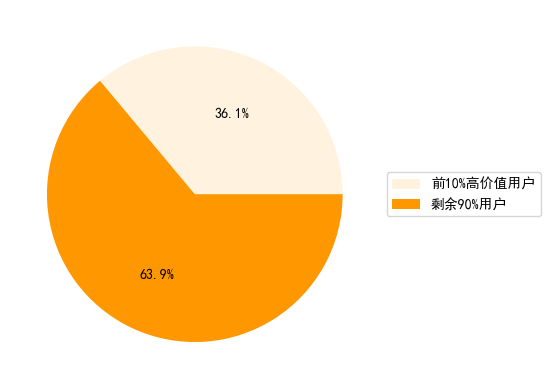

In [14]:
top10_ratio = top_user.sum()/df['购买金额'].sum()
other_ratio = 1-top10_ratio
plt.pie([top10_ratio,other_ratio],autopct='%.1f%%',colors=['#fff3e0','#ff9800'])
plt.legend(['前10%高价值用户','剩余90%用户'],loc='center left',bbox_to_anchor=(1,0.5))

7.前10%的高价值用户贡献了36%的销售额，这不符合二八定律，符合三七定律。

#### 6.不同城市偏好的TOP3商品类别是什么？（A/B/C城市差异）

(array([0, 1, 2]), [Text(0, 0, 'A'), Text(1, 0, 'B'), Text(2, 0, 'C')])

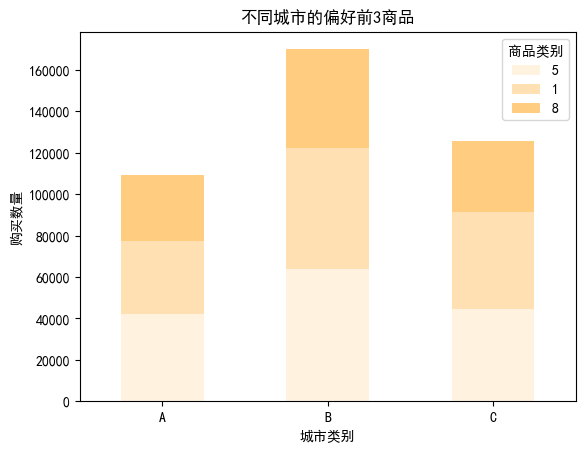

In [15]:
city_top3_product = df.groupby('城市类别')['商品类别'].value_counts().groupby(level=0).head(3)   # .groupby(level=0)是按第0层索引继续分组 再取前三
city_top3_product.unstack().plot(kind='bar',stacked=True,color = ['#fff3e0','#ffe0b2','#ffcc80'])
plt.title('不同城市的偏好前3商品',fontsize=12,weight='bold')
plt.xlabel('城市类别',fontsize=10)
plt.ylabel('购买数量',fontsize=10)
plt.xticks(rotation=0)

8.A、B、C城市偏好的商品前三都是5、1、8。

#### 7.居住时长与消费金额的关系？老居民 vs 新居民谁消费更高？

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4+')])

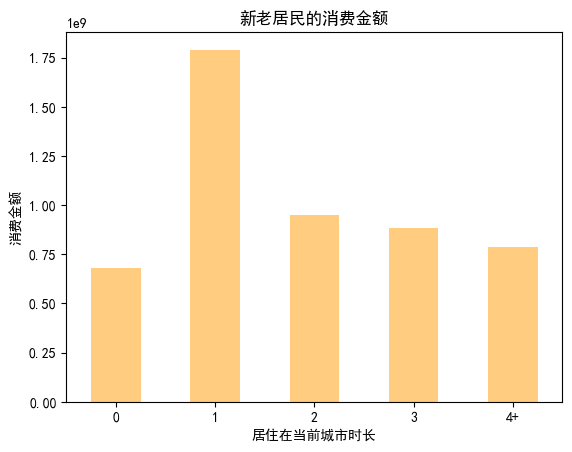

In [16]:
df.groupby('居住在当前城市时长')['购买金额'].sum().plot(kind='bar',color='#ffcc80')
plt.title('新老居民的消费金额',fontsize=12,weight='bold')
plt.xlabel('居住在当前城市时长',fontsize=10)
plt.ylabel('消费金额',fontsize=10)
plt.xticks(rotation=0)

9.居住一年的居民消费最高，猜测是购买家具、人生消费高峰期（结婚、生子）等原因。其余居民消费相近。

#### 8.不同职位（职业代码）的消费金额排名？高收入职业偏好哪些商品？

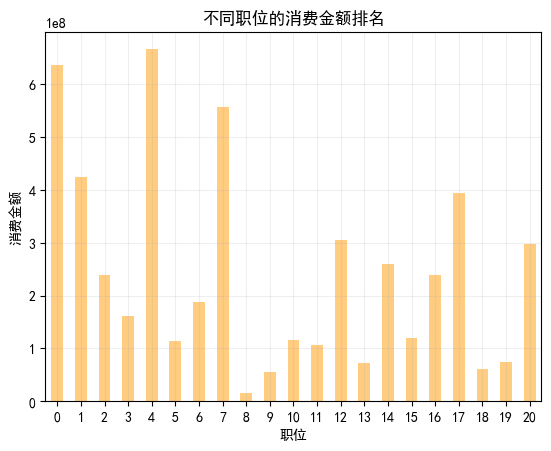

In [113]:
high_salary = df.groupby('职位')['购买金额'].sum().sort_values(ascending=False)
high_salary.sort_index().plot(kind='bar',color='#ffcc80')
plt.title('不同职位的消费金额排名',fontsize=12,weight='bold')
plt.xlabel('职位',fontsize=10)
plt.ylabel('消费金额',fontsize=10)
plt.xticks(rotation=0)
plt.grid(alpha=0.2)

10.消费排名前5的依次是4、0、7、1、17。

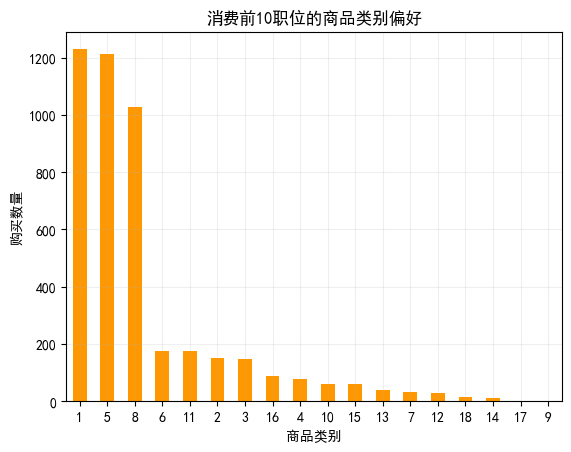

In [112]:
high_salary_top10 = high_salary.head(10)
df[df['职位'].isin(high_salary_top10.index)].drop_duplicates(subset=['用户号'])['商品类别'].value_counts().plot(kind='bar',color='#ff9800')
plt.title('消费前10职位的商品类别偏好',fontsize=12,weight='bold')
plt.xlabel('商品类别',fontsize=10)
plt.ylabel('购买数量',fontsize=10)
plt.xticks(rotation=0)
plt.grid(alpha=0.2)

11.消费前10职位偏好前3依次是1、5、8，远高于其他类别。

#### 9.最常一起购买的商品类别组合是哪些？（购物篮分析）

In [18]:
top3_product = df['商品类别'].value_counts().head(10)

basket_category = df[df['商品类别'].isin(top3_product.index)].groupby(['用户号','商品类别'])['购买金额'].sum().unstack().fillna(0)
basket_category_binary = basket_category.map(lambda x: 1 if x>0 else 0 )
#频繁项集
frequent_itemset_cat = apriori(basket_category_binary,min_support=0.03,use_colnames=True)
# 关联规则
rules_cat = association_rules(frequent_itemset_cat,metric='confidence',min_threshold=0.5)
rules_cat_sort = rules_cat.sort_values('lift',ascending=False)
print(rules_cat_sort[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

C:\Users\29408\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


                          antecedents                     consequents  \
41777     frozenset({1, 2, 3, 6, 11})    frozenset({4, 5, 8, 15, 16})   
39859       frozenset({8, 16, 4, 15})     frozenset({1, 2, 3, 6, 11})   
41584  frozenset({1, 2, 3, 5, 6, 11})       frozenset({8, 16, 4, 15})   
39660     frozenset({1, 2, 3, 6, 11})       frozenset({8, 16, 4, 15})   
41968    frozenset({4, 5, 8, 15, 16})     frozenset({1, 2, 3, 6, 11})   
42098       frozenset({8, 16, 4, 15})  frozenset({1, 2, 3, 5, 6, 11})   
41878     frozenset({2, 3, 5, 6, 11})    frozenset({1, 4, 8, 15, 16})   
39710    frozenset({1, 4, 8, 15, 16})        frozenset({11, 2, 3, 6})   
41337       frozenset({8, 16, 4, 15})     frozenset({2, 3, 5, 6, 11})   
41245    frozenset({4, 5, 8, 15, 16})        frozenset({11, 2, 3, 6})   

        support  confidence      lift  
41777  0.177219    0.515301  2.333312  
39859  0.177219    0.802460  2.333312  
41584  0.177219    0.515301  2.333312  
39660  0.177219    0.515301  2.33331

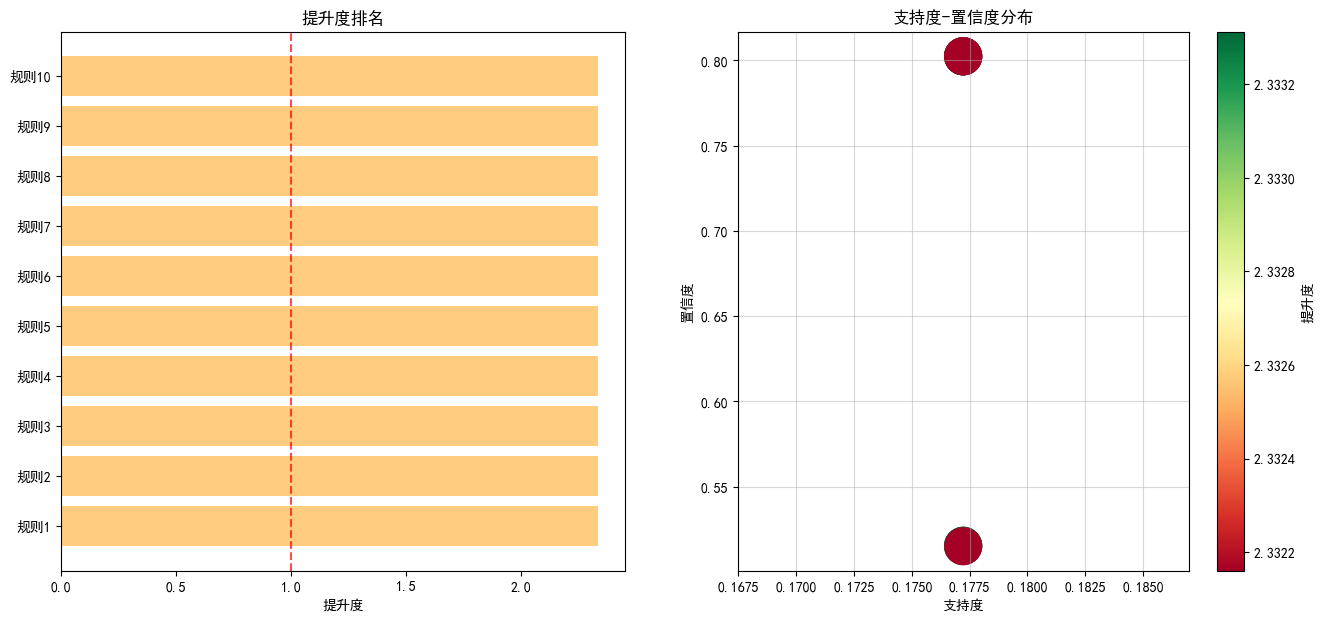

In [40]:
top10 = rules_cat_sort.head(10)
plt.figure(figsize=(16,7))
plt.subplot(121)
plt.barh(range(len(top10)),top10['lift'],color='#ffcc80')
plt.yticks(range(len(top10)),[f"规则{i+1}" for i in range(len(top10))])
plt.xlabel('提升度')
plt.title('提升度排名')
plt.axvline(x=1,color='red',linestyle='--',alpha=0.7)

plt.subplot(122)
plt.scatter(top10['support'],top10['confidence'],s=top10['lift']*300,c=top10['lift'],cmap='RdYlGn')
plt.title('支持度-置信度分布')
plt.xlabel('支持度')
plt.ylabel('置信度')
plt.colorbar(label='提升度')
plt.grid(alpha=0.5)

12.商品类别 {4,5,8,15,16} 和 {1,2,3,5,6,11} 形成强关联组合，购买前者（尤其是类别5）的用户有80%的概率会购买后者，建议捆绑销售或交叉推荐。

#### 10.年轻群体(0-35）vs 中老年群体（36+）的消费习惯差异？

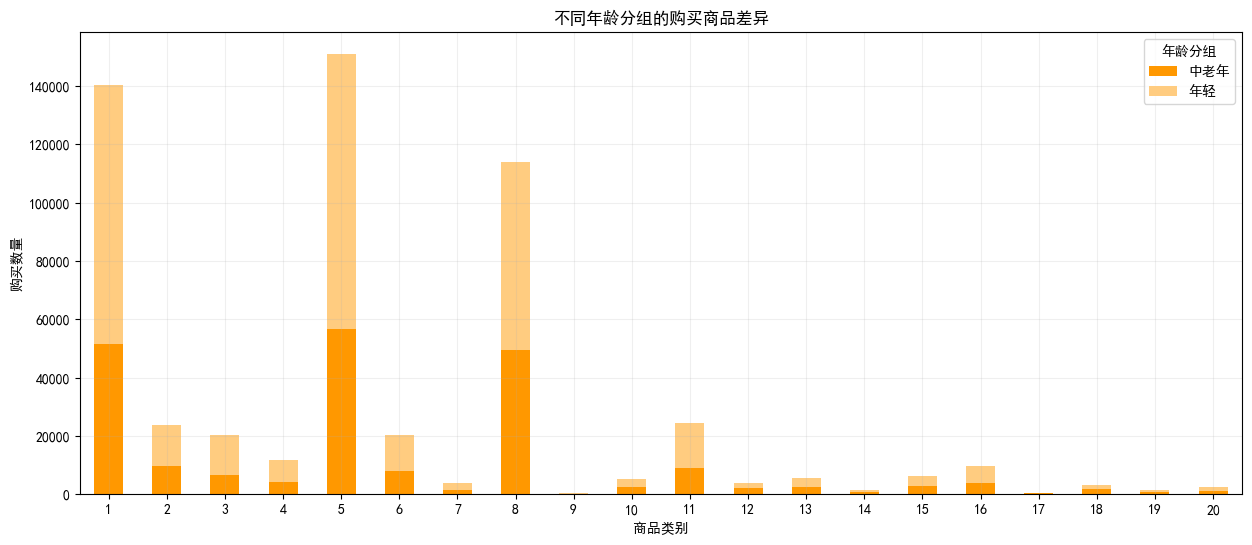

In [115]:
age_map = {
    '0-17': '年轻',
    '18-25': '年轻',
    '26-35': '年轻',
    '36-45': '中老年',
    '46-50': '中老年',
    '51-55': '中老年',
    '55+': '中老年'
}
df['年龄分组'] = df['年龄'].map(age_map)
df.groupby('年龄分组')['商品类别'].value_counts().unstack(0).plot(kind='bar',figsize=(15,6),stacked=True,color=['#ff9800','#ffcc80'])  # 想让年龄分组成为折线 就unstack他的索引
plt.title('不同年龄分组的购买商品差异',fontsize=12,weight='bold')
plt.xlabel('商品类别',fontsize=10)
plt.ylabel('购买数量',fontsize=10)
plt.xticks(rotation=0)
plt.grid(alpha=0.2)

13.年轻群体购买力普遍比中老年群体高。

#### 11.哪些用户购买次数最多？高频用户有什么特征？

In [62]:
top100 = df['用户号'].value_counts().head(100)
high_fre_user = df[df['用户号'].isin(top100.index)].drop_duplicates(subset=['用户号'])   # 基于'用户号'去重，每个用户只保留第一条记录
high_fre_user

,用户号,商品号,性别1,年龄,职位,城市类别,居住在当前城市时长,婚姻状况1,商品类别,购买金额,性别,婚姻状况,年龄分组
1152,1000195,P00031042,M,26-35,12,B,4+,1,8,9761,男,已婚,年轻
2263,1000352,P00278642,M,18-25,4,A,0,0,5,8877,男,未婚,年轻
2619,1000424,P00246142,M,26-35,17,A,3,0,1,15802,男,未婚,年轻
3172,1000524,P00346542,M,18-25,0,A,0,0,10,23728,男,未婚,年轻
3235,1000531,P00307342,F,18-25,14,B,0,0,8,7764,女,未婚,年轻
...,...,...,...,...,...,...,...,...,...,...,...,...,...
37761,1005812,P00057642,F,26-35,7,A,1,1,1,19364,女,已婚,年轻
37870,1005831,P00224142,M,26-35,1,A,2,1,8,7998,男,已婚,年轻
38619,1005954,P00310542,M,46-50,11,A,2,1,8,5879,男,已婚,中老年
39029,1006016,P00282442,M,46-50,1,B,1,1,5,6989,男,已婚,中老年


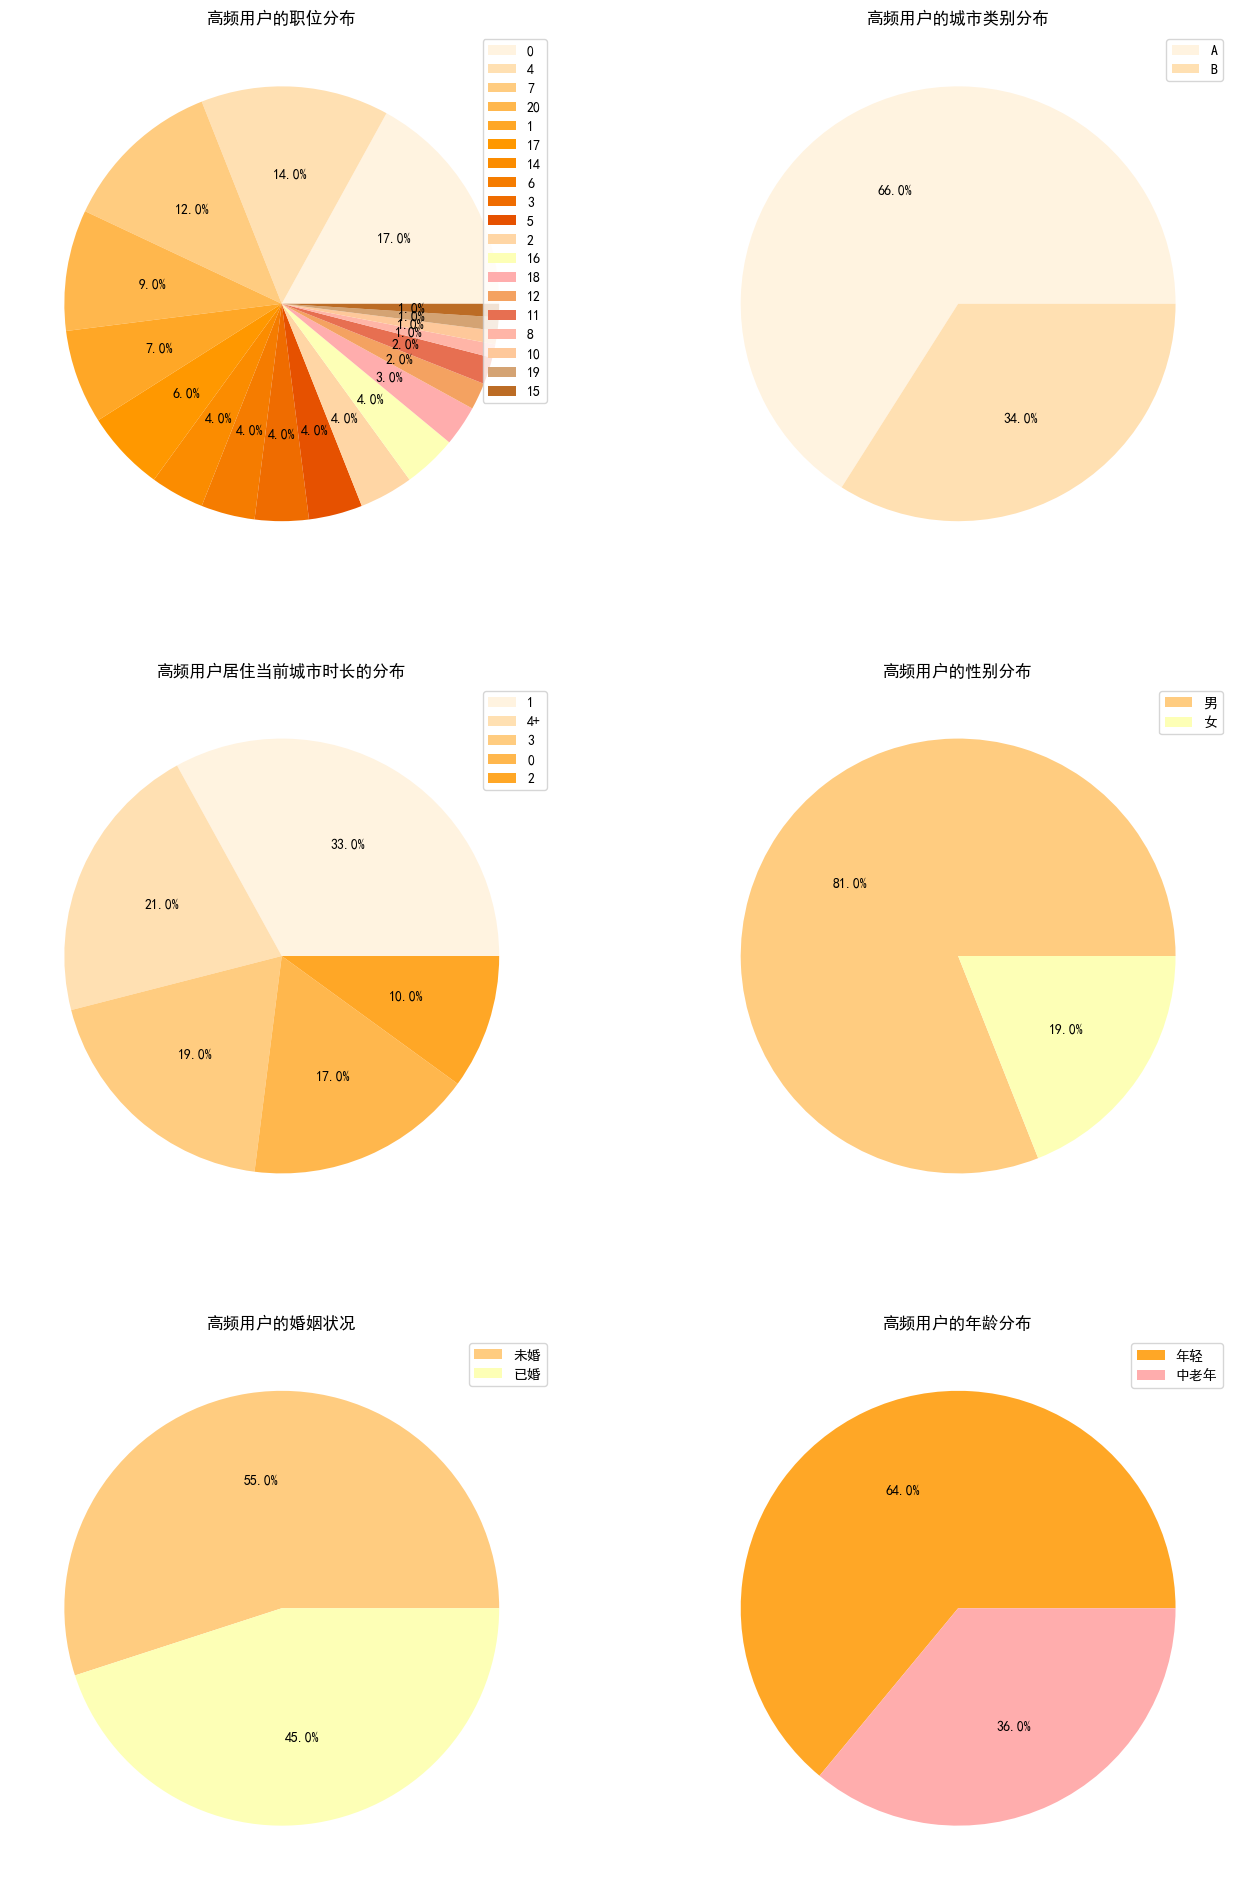

In [70]:
plt.figure(figsize=(16,24))
plt.subplot(321)
p1 = high_fre_user['职位'].value_counts()
p1.plot(kind='pie',autopct='%.1f%%',labels=None,colors= ['#fff3e0','#ffe0b2','#ffcc80','#ffb74d','#ffa726','#ff9800','#fb8c00','#f57c00','#ef6c00','#e65100','#ffd6a5','#fdffb6','#ffadad','#f4a261','#e76f51','#ffb5a7','#fec89a','#d4a373','#bc6c25','#9c6644'])
plt.title('高频用户的职位分布')
plt.legend(p1.index,loc='upper right')

plt.subplot(322)
p2 = high_fre_user['城市类别'].value_counts()
p2.plot(kind='pie',autopct='%.1f%%',labels=None,colors= ['#fff3e0','#ffe0b2'])
plt.title('高频用户的城市类别分布')
plt.legend(p2.index,loc='upper right')

plt.subplot(323)
p3 = high_fre_user['居住在当前城市时长'].value_counts()
p3.plot(kind='pie',autopct='%.1f%%',labels=None,colors= ['#fff3e0','#ffe0b2','#ffcc80','#ffb74d','#ffa726','#ff9800','#fb8c00','#f57c00','#ef6c00','#e65100','#ffd6a5','#fdffb6','#ffadad','#f4a261','#e76f51','#ffb5a7','#fec89a','#d4a373','#bc6c25','#9c6644'])
plt.title('高频用户居住当前城市时长的分布')
plt.legend(p3.index,loc='upper right')

plt.subplot(324)
p4 = high_fre_user['性别'].value_counts()
p4.plot(kind='pie',autopct='%.1f%%',labels=None,colors= ['#ffcc80','#fdffb6'])
plt.title('高频用户的性别分布')
plt.legend(p4.index,loc='upper right')

plt.subplot(325)
p5 = high_fre_user['婚姻状况'].value_counts()
p5.plot(kind='pie',autopct='%.1f%%',labels=None,colors= ['#ffcc80','#fdffb6'])
plt.title('高频用户的婚姻状况')
plt.legend(p5.index,loc='upper right')

plt.subplot(326)
p6 = high_fre_user['年龄分组'].value_counts()
p6.plot(kind='pie',autopct='%.1f%%',labels=None,colors= ['#ffa726','#ffadad'])
plt.title('高频用户的年龄分布')
plt.legend(p6.index,loc='upper right')

14.高频用户职位主要分布在0、4、7、20，66%居住在A城市，居住时长大多数在1年或4年以上，81%为男性，55%未婚，64%是年轻群体。

#### 12.最典型的高频用户画像是什么？（例：26-35岁_男性_C城市_已婚_职位X）


【典型高频用户画像】
  职位: 0
  城市类别: A
  性别: 男
  婚姻状况: 未婚
  年龄分组: 26-35
  最典型高频用户总消费占高频用户总消费：5.09%


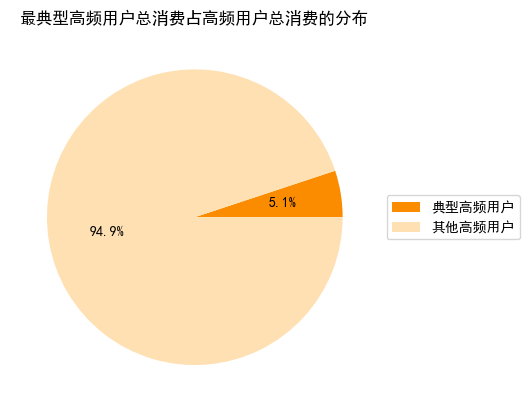

In [100]:
typical_age = high_fre_user['年龄'].mode()[0]
typical_gender = high_fre_user['性别'].mode()[0]
typical_city = high_fre_user['城市类别'].mode()[0]
typical_marital = high_fre_user['婚姻状况'].mode()[0]
typical_occupation = high_fre_user['职位'].mode()[0]
print(f"\n【典型高频用户画像】")
print(f"  职位: {typical_occupation}")
print(f"  城市类别: {typical_city}")
print(f"  性别: {typical_gender}")
print(f"  婚姻状况: {typical_marital}")
print(f"  年龄分组: {typical_age}")

typical_user = high_fre_user[(high_fre_user['年龄'] == typical_age) & (high_fre_user['性别'] == typical_gender) &
    (high_fre_user['城市类别'] == typical_city) & (high_fre_user['婚姻状况'] == typical_marital) & (high_fre_user['职位'] == typical_occupation)]
ratio = round(typical_user['购买金额'].sum()/(high_fre_user['购买金额'].sum())*100,2)
print(f"  最典型高频用户总消费占高频用户总消费：{ratio}%")

t1 = typical_user['购买金额'].sum()
t2 = high_fre_user['购买金额'].sum()-t1
plt.pie([t1,t2],colors=['#fb8c00','#ffe0b2'],autopct="%.1f%%")
plt.title('最典型高频用户总消费占高频用户总消费的分布')
plt.legend(['典型高频用户','其他高频用户'],loc='center left',bbox_to_anchor=(1,0.5))

15.最典型高频用户总消费占高频用户总消费：5.09% ，意味着用户画像多样化，没有单一"绝对统治者"用户画像，消费分布比较分散；长尾特征明显，说明最典型的用户群体规模较小，消费贡献被更多其他用户分摊。

In [117]:
# 分布类型	   前10%用户贡献	      最典型用户贡献    	特征
# 二八定律       60-80%	          20-30%	      少数超级用户主导
# 三七定律       30-40%
# 长尾分布	    <30%	        <5%	             大量中小用户贡献
# 正态分布	    约10%	       约1-2%	        用户贡献非常平均


### 结论：
1.26-35年龄段消费能力最强，其次为36-45、18-25,可见青年中年群体为消费主力，0-17年龄段消费能力最弱。

2.每个年龄段都偏好5、1、8商品。

3.未婚人士的消费水平高于已婚人士，且已婚男士消费水平远高于已婚女士，未婚男士的消费水平也远高于未婚女士。

4.已婚女士偏好5，已婚男士偏好5、1，未婚女士偏好5，未婚男士偏好5、1。

5.A城市消费水平最高，其次是B，C最低，但是A与B消费水平相当接近。

6.前10%的高价值用户年龄居于26-35的最多，80%是男人，大多数居住在A、B城市，60%未婚，职位最多的是0，其次为4、7。

7.前10%的高价值用户贡献了36%的销售额，这不符合二八定律，符合三七定律。

8.A、B、C城市偏好的商品前三都是5、1、8。

9.居住一年的居民消费最高，猜测是购买家具、人生消费高峰期（结婚、生子）等原因。其余居民消费相近。

10.消费排名前5的依次是4、0、7、1、17。

11.消费前10职位偏好前3依次是1、5、8，远高于其他类别。

12.商品类别 {4,5,8,15,16} 和 {1,2,3,5,6,11} 形成强关联组合，购买前者（尤其是类别5）的用户有80%的概率会购买后者，建议捆绑销售或交叉推荐。

13.年轻群体购买力普遍比中老年群体高。

14.高频用户职位主要分布在0、4、7、20，66%居住在A城市，居住时长大多数在1年或4年以上，81%为男性，55%未婚，64%是年轻群体。

15.最典型高频用户总消费占高频用户总消费：5.09% ，意味着用户画像多样化，没有单一"绝对统治者"用户画像，消费分布比较分散；长尾特征明显，说明最典型的用户群体规模较小，消费贡献被更多其他用户分摊。